In [ ]:
import pandas as pd
relevant_data_uncleaned = pd.read_csv('data/relevant_data_uncleaned.csv')

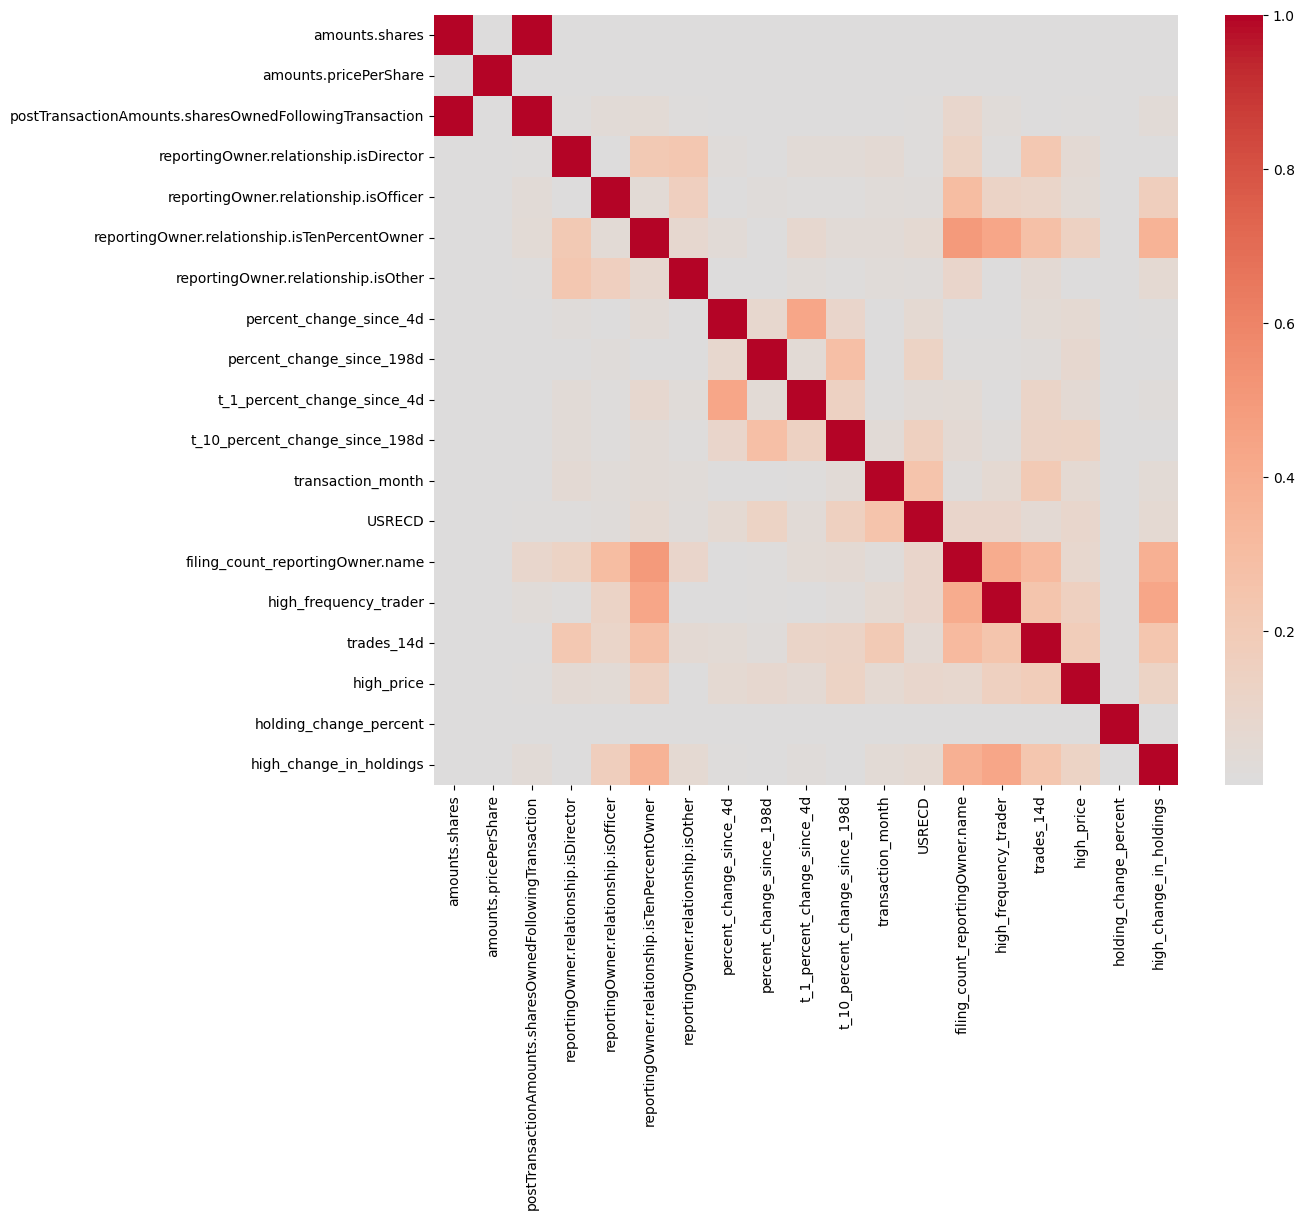

In [ ]:
import seaborn as sns

def plot_heatmap(df):
    corr_matrix = df.corr(numeric_only=False).abs()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
    plt.show() 

plot_heatmap(relevant_data_uncleaned)

KeyboardInterrupt: 

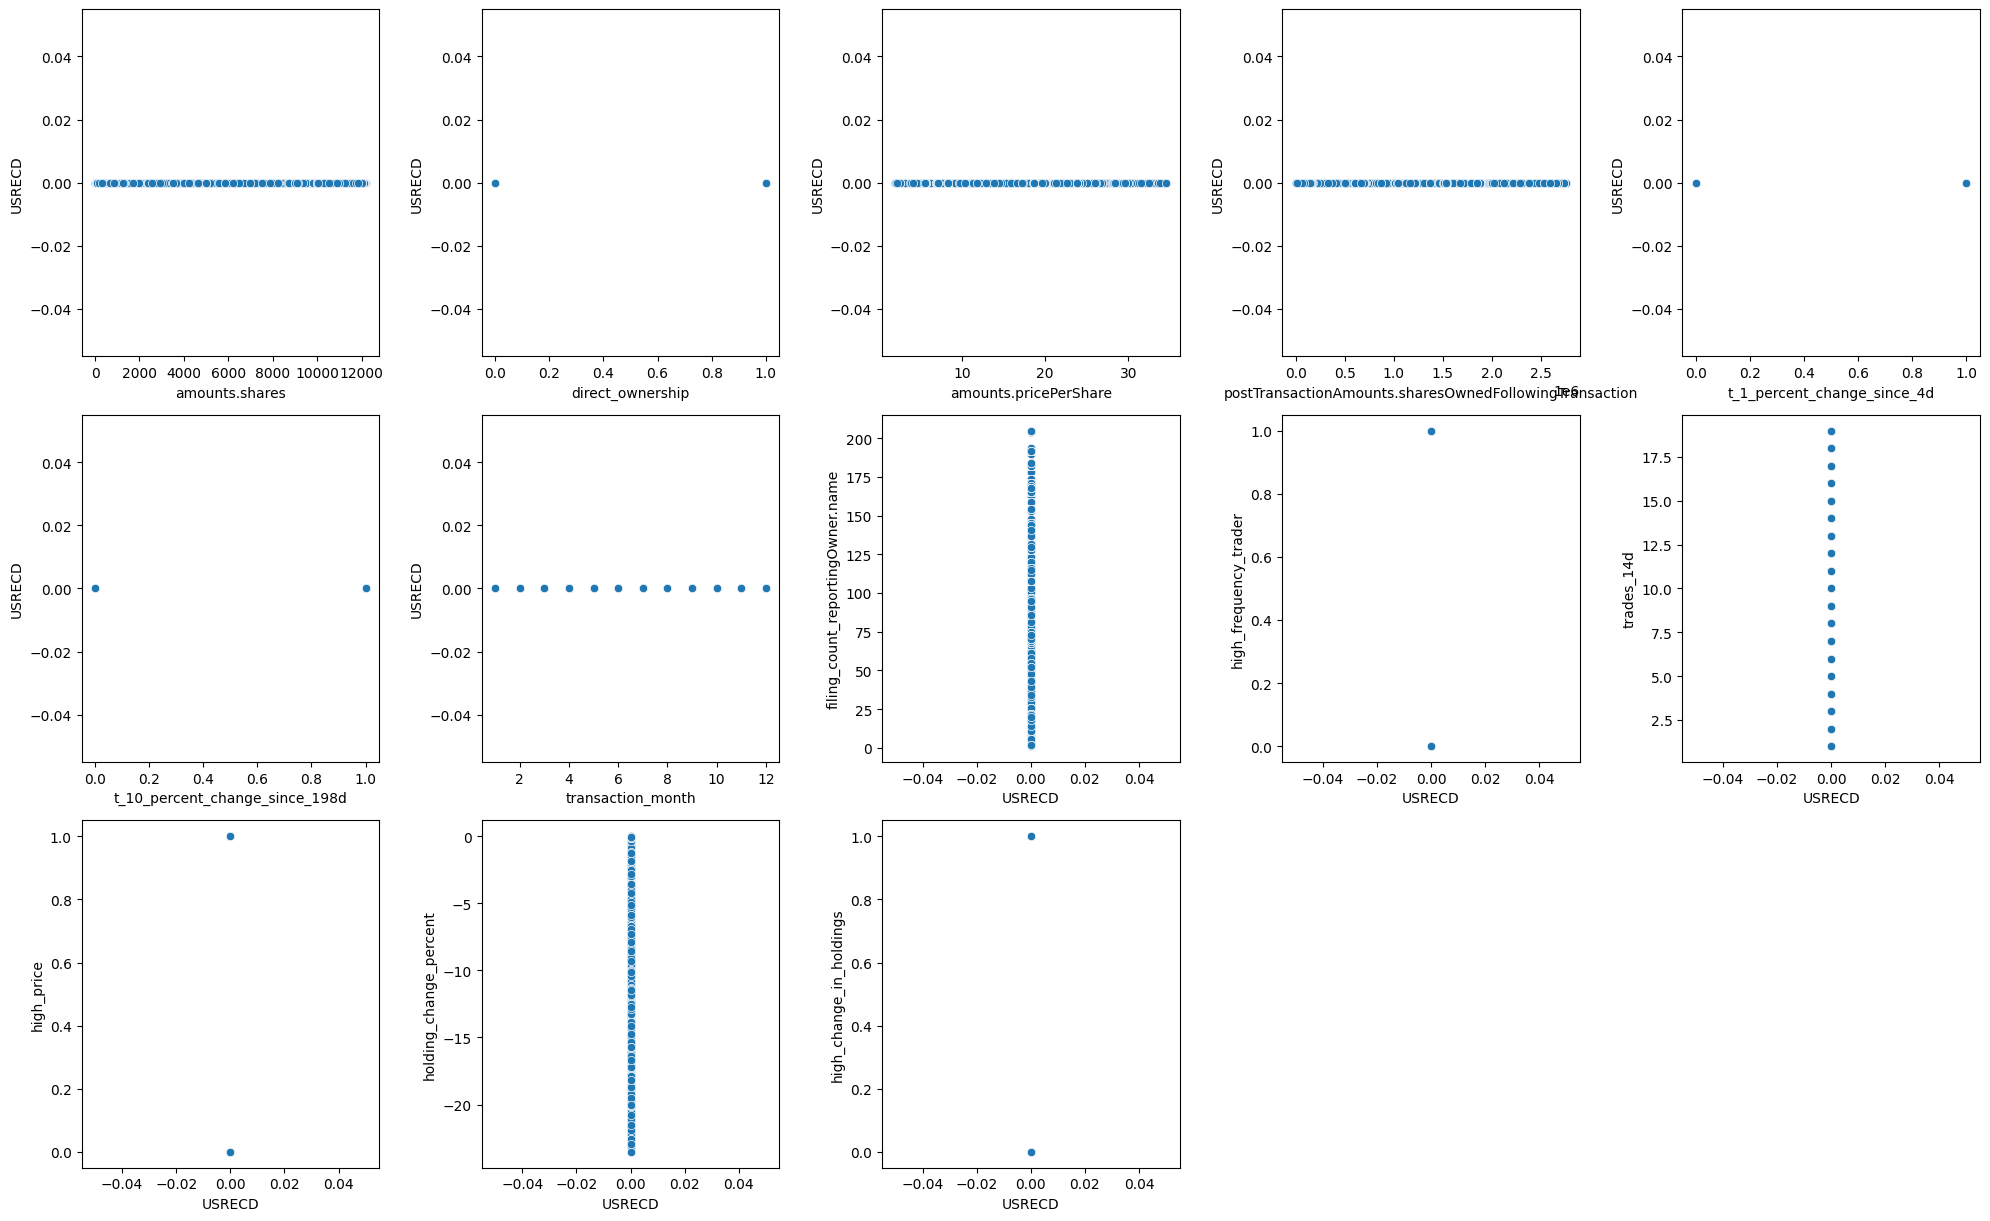

In [23]:
import itertools
import seaborn as sns
import os
def scatterplot(df, variable=None, target_compare="target"):
    """
    Macht Scatterplots für jede Kombination der übergebenen Variablen und speichert alle gemeinsam als Grid.

    Input:
        df (pd.DataFrame): unsere aktuellen Daten
        variable (list): Liste mit Variablen 2 für Einzel-Scatterplot oder wenn None dann werden alle Variablen geplottet
        target_compare (str): Zielvariable für die Farbe (Hue)
    """

    if variable is not None:
        x, y = variable
        sns.scatterplot(data=df, x=x, y=y, hue=target_compare if target_compare in df.columns else None)
        plt.tight_layout()
        plt.savefig(f'exports/scatterplot/scatter_{x}_und_{y}.png', dpi=300)
        plt.close()
        return

    # Plots für alle Variablen
    variablen = df.select_dtypes(include='number').columns.tolist()
    kombis = list(itertools.combinations(variablen, 2))

    # Für jede Variable v ein eigenes Grid
    for v in variablen:
        relevante_kombis = [(x_var, y_var) for x_var, y_var in kombis if v in (x_var, y_var)]

        fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
        axes = axes.flatten()

        for idx, (x_var, y_var) in enumerate(relevante_kombis):
            if idx >= len(axes):
                break
            sns.scatterplot(
                data=df,
                x=x_var,
                y=y_var,
                hue=target_compare if target_compare in df.columns else None,
                ax=axes[idx]                        # <-- hier!
            )

        # Restliche leere Achsen entfernen
        for ax in axes[len(relevante_kombis):]:
            fig.delaxes(ax)

        plt.tight_layout()
        plt.savefig(f'exports/scatterplot/scatter.png', dpi=300)
        plt.close()

scatterplot(relevant_data_without_outlires, variable=None, target_compare="target")


In [3]:
from data_cleaning import count_outlires
columns = ['amounts.shares',
                  'amounts.pricePerShare',
                  'postTransactionAmounts.sharesOwnedFollowingTransaction',
                  #'reportingOwner.relationship.isDirector',
                  #'reportingOwner.relationship.isOfficer',
                  #'reportingOwner.relationship.isTenPercentOwner',
                  #'reportingOwner.relationship.isOther',
                  'percent_change_since_4d',
                  'percent_change_since_198d',
                  #'t_1_percent_change_since_4d',
                  #'t_10_percent_change_since_198d',
                  #'transaction_month',
                  #'USRECD',
                  #'filing_count_reportingOwner.name',
                  #'high_frequency_trader',
                  #'trades_14d', 'high_price',
                  'holding_change_percent',
                  #'high_change_in_holdings'
                  ]
df_important = df[columns]


In [13]:
from data_cleaning import stats
columns = ['amounts.shares',
                  'amounts.pricePerShare',
                  'postTransactionAmounts.sharesOwnedFollowingTransaction',
                  #'reportingOwner.relationship.isDirector',
                  #'reportingOwner.relationship.isOfficer',
                  #'reportingOwner.relationship.isTenPercentOwner',
                  #'reportingOwner.relationship.isOther',
                  'percent_change_since_4d',
                  'percent_change_since_198d',
                  #'t_1_percent_change_since_4d',
                  #'t_10_percent_change_since_198d',
                  #'transaction_month',
                  #'USRECD',
                  #'filing_count_reportingOwner.name',
                  #'high_frequency_trader',
                  #'trades_14d', 'high_price',
                  'holding_change_percent',
                  #'high_change_in_holdings'
                  ]
df_important = df[columns]

import numpy as np
import pandas as pd

def count_outliers(df, columns=None, iqr_k=1.5):
    cols = df.columns if columns is None else list(columns)

    # 1) Alles numerisch erzwingen (Nicht-Numerisches -> NaN)
    num = df[cols].apply(pd.to_numeric, errors='coerce')

    # 3) Quantile/IQR
    Q1 = num.quantile(0.25)
    Q3 = num.quantile(0.75)
    IQR = (Q3 - Q1).astype(float)

    # 4) Grenzen + Outlier-Maske (spaltenweise Alignment!)
    lb = (Q1 - float(iqr_k) * IQR).astype(float)
    ub = (Q3 + float(iqr_k) * IQR).astype(float)
    mask = num.lt(lb, axis=1) | num.gt(ub, axis=1)

    return mask.sum().sort_values(ascending=False)
 

#stats(df_important)
count_outliers(df_important, column)


postTransactionAmounts.sharesOwnedFollowingTransaction    23541
holding_change_percent                                    22091
amounts.shares                                            19107
percent_change_since_4d                                   13612
percent_change_since_198d                                  9221
amounts.pricePerShare                                      3326
dtype: int64

In [16]:


def Ausreißer(df, default_outlier_strategy = "delete", except_replace_0=[], except_replace_mean=[], except_delete=[], ignore=[]):
    cols = df.columns
    df = df[cols].apply(pd.to_numeric, errors='coerce')
    for cols in df.select_dtypes(include=['number']).columns:
        if cols in ignore: 
            continue
        # Q1, Q3 und IQR berechnen
        Q1 = df[cols].quantile(0.25)
        Q3 = df[cols].quantile(0.75)
        IQR = Q3 - Q1

        # Definiere die Grenzen für Ausreißer
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        if cols in except_replace_0:
            df.loc[:, cols] = df[cols].apply(
                lambda x: 0 if x < lower_bound or x > upper_bound else x)
        elif cols in except_replace_mean:
            mean_val = df[cols].mean()
            df.loc[:, cols] = df[cols].apply(
                lambda x: mean_val if x < lower_bound or x > upper_bound else x)
        elif cols in except_delete:
            df = df[~((df[cols] < lower_bound) | (df[cols] > upper_bound))]
        else:
            # Default Strategie
            if default_outlier_strategy == "replace_0":
                df[cols] = df[cols].apply(
                    lambda x: 0 if x < lower_bound or x > upper_bound else x)
            elif default_outlier_strategy == "replace_mean":
                mean_val = df[cols].mean()
                df[cols] = df[cols].apply(
                    lambda x: mean_val if x < lower_bound or x > upper_bound else x)
            elif default_outlier_strategy == "delete":
                df = df[~((df[cols] < lower_bound) | (df[cols] > upper_bound))]
    return df
#Ausreißer(relevant_data_uncleaned, default_outlier_strategy = "delete", except_replace_0=[], except_replace_mean=[], except_delete=[], ignore=[])

In [22]:
relevant_data_without_outlires = Ausreißer(relevant_data_uncleaned, default_outlier_strategy = "delete", except_replace_0=[], except_replace_mean=[], except_delete=[], ignore=[])

In [24]:
def Varianz(df, variance_threshold = 0.1, target_corr_threshold = 0.2, df_name="df", target_col="TF_Kündiger", never_drop=["TF_Kündiger"]):
    """
    Berechnet die Varianz jeder Variable.
    var() ist äquivalent zu VARIANZA() in Excel für Binäre Variable und VAR.P() für die restlichen numerischen Variablen in Excel.
        
    Input:
        df (pd.DataFrame): unsere aktuellen Daten
        variance_threshold (float): Grenzwert für Varianz für das Entfernen der Variablen 
        target_corr_threshold (float): Grenzwert für Korrelation mit Targetvariable für das Entfernen der Variablen 
        df_name (string): Name vom verwendeten df, T1_df, T2_df oder diff_df. Das wird für die Log Dokumentation benötigt.
        target_col (string): als Hilfe für die Berechnung der Korrelation mit der Target Variable
        never_drop (list): Wenn man vermeiden will, dass eine bestimmt Variable gelöst wird, speichert man sie hier als Liste ab
    
    Output:
        Neues df (pd.DataFrame): ohne Variablen mit niedriger Varianz unter dem Wert festgelegt mit variance_threshold
        Print Statement: Liste aller entfernten Variablen
    """
    variances = df.var(skipna=True, ddof=1) # ddof=1 für Stichprobenvarianz; 0 wäre Populationsvarianz

    low_variance_columns = list(variances[(variances < variance_threshold)].index)

    # Korrelation mit Zielvariable berechnen
    corr_with_target = df.corr(method='pearson')[target_col].abs()

    # Varianz = 0 kann schon mal in die to_drop liste
    to_drop = []
    
    # Nur Variablen entfernen, die auch eine niedrige Korrelation zur Zielvariable haben
    for var in low_variance_columns:
        if var in never_drop:
            continue  # nicht löschen, weil in never_drop-Liste
            
        var_target_corr = corr_with_target.get(var, 0)

        if var_target_corr > target_corr_threshold:
            print(f"In {df_name} hat '{var}' niedrige Varianz mit {variances[var]:.6f}, aber hohe Korrelation mit {target_col} {var_target_corr:.3f} wird behalten.")

        else:
            to_drop.append(var)
       
    # Variablen mit niedriger Varianz aus dem df entfernen
    df = df.drop(columns=to_drop)
    
    if not to_drop:
        print(f"In {df_name} wurden keine Spalten wegen zu geringer Varianz entfernt.")
    else:
        print(f"Entfernte Spalten in {df_name} mit niedriger Varianz und geringer Korrelation mit {target_col}:")
        for col in to_drop:
            print(f"{col}: Varianz = {variances[col]:.6f}, Korrelation mit {target_col} = {corr_with_target[col]:.3f}")
    print("-------------------------------------------------------------------------------------------")
        
    return df
Varianz(relevant_data_without_outlires, 
        variance_threshold = 0.1,
        target_corr_threshold = 0.2,
        df_name="relevant_data_without_outlires",
        target_col="t_1_percent_change_since_4d",
        never_drop=["t_1_percent_change_since_4d"])

Entfernte Spalten in relevant_data_without_outlires mit niedriger Varianz und geringer Korrelation mit t_1_percent_change_since_4d:
reportingOwner.relationship.isTenPercentOwner: Varianz = 0.091504, Korrelation mit t_1_percent_change_since_4d = 0.039
reportingOwner.relationship.isOther: Varianz = 0.061755, Korrelation mit t_1_percent_change_since_4d = 0.041
USRECD: Varianz = 0.000000, Korrelation mit t_1_percent_change_since_4d = nan
-------------------------------------------------------------------------------------------


,amounts.shares,direct_ownership,amounts.pricePerShare,postTransactionAmounts.sharesOwnedFollowingTransaction,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,t_1_percent_change_since_4d,t_10_percent_change_since_198d,transaction_month,filing_count_reportingOwner.name,high_frequency_trader,trades_14d,high_price,holding_change_percent,high_change_in_holdings
5795,2000.0,0,2.25,295126.0,True,False,1,1,7,14,0,3.0,0,-0.682300,1
5796,100.0,0,2.20,295226.0,True,False,1,1,7,14,0,3.0,0,-0.033884,1
5799,1000.0,1,5.05,484700.0,False,False,1,1,7,104,1,4.0,0,-0.206740,1
5800,2000.0,1,5.00,486700.0,False,False,1,1,7,104,1,4.0,0,-0.412626,1
5801,1000.0,1,4.95,487700.0,False,False,1,1,7,104,1,4.0,0,-0.205465,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141051,100.0,1,23.81,2446.0,True,False,1,0,7,22,0,6.0,1,-4.262575,0
141052,100.0,1,4.08,66670.0,True,True,0,0,7,43,1,2.0,0,-0.150218,1
141053,164.0,1,19.64,4737.0,True,False,1,0,7,21,0,1.0,1,-3.586267,0
141054,306.0,1,10.30,16886.0,True,False,1,1,7,18,0,1.0,1,-1.845597,0
